# Calibración de probabilidades y Brier score

## Objetivos 

En esta sesión se busca:

1. Analizar la calidad de las probabilidades predichas por los modelos.
2. Introducir el concepto de **calibración** en clasificación binaria.
3. Calcular el **Brier score** para comparar modelos.
4. Construir curvas de calibración.
5. Contrastar discriminación y calibración en:
   - regresión logística,
   - árbol de decisión,
   - Random Forest.

## Contexto

En sesiones anteriores se compararon varios modelos usando métricas como `accuracy`, `recall`, `F1-score` y `ROC-AUC`. Sin embargo, estas medidas se enfocan sobre todo en la capacidad del modelo para clasificar o discriminar observaciones.

En muchos problemas aplicados, especialmente en riesgo crediticio, también es importante que las probabilidades predichas sean **creíbles**. Es decir, si el modelo asigna una probabilidad de incumplimiento cercana a 0.40, conviene que, en promedio, aproximadamente 40% de los clientes con ese nivel de riesgo realmente incumplan.

Esta propiedad se conoce como **calibración**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [5]:
df = pd.read_csv("default_credit_clean.csv")

if "default payment next month" in df.columns:
    df = df.rename(columns={"default payment next month": "default_next_month"})

if "AGE_GROUP" not in df.columns:
    bins = [20, 30, 40, 50, 60, 80]
    labels = ["20-29", "30-39", "40-49", "50-59", "60+"]
    df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist()[:10])
df.head()


Dimensiones del dataset: (30000, 29)

Primeras columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Femenino,Universidad,Casado,20-29
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Femenino,Universidad,Soltero,20-29
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Femenino,Universidad,Soltero,30-39
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Femenino,Universidad,Casado,30-39
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Masculino,Universidad,Casado,50-59


## Separación de predictores y variable objetivo

En esta sección se define:

- `X`: conjunto de variables predictoras,
- `y`: variable objetivo `default_next_month`.

También se eliminan columnas que no deben entrar directamente al modelado, como el identificador `ID` y las etiquetas auxiliares de texto.

In [6]:
cols_to_drop = ["default_next_month"]
optional_drop = ["ID", "SEX_LABEL", "EDUCATION_LABEL", "MARRIAGE_LABEL"]

for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nColumnas de X:")
print(X.columns.tolist())

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)

Columnas de X:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_GROUP']


## División en entrenamiento y prueba

Para comparar de forma justa la calibración de probabilidades entre modelos, se utilizará la misma partición en entrenamiento y prueba que en sesiones anteriores.

La partición será:

- **80%** para entrenamiento,
- **20%** para prueba,

y además será **estratificada**, para conservar aproximadamente la misma proporción de incumplimiento en ambos subconjuntos.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporción de incumplimiento en y_train:", y_train.mean())
print("Proporción de incumplimiento en y_test :", y_test.mean())

X_train: (24000, 24)
X_test : (6000, 24)
y_train: (24000,)
y_test : (6000,)

Proporción de incumplimiento en y_train: 0.22120833333333334
Proporción de incumplimiento en y_test : 0.22116666666666668


## Identificación de variables numéricas y categóricas

Antes de entrenar los modelos, se distinguen las variables que serán tratadas como:

- **categóricas**, usando codificación `one-hot`,
- **numéricas**, usando imputación y, en el caso de la regresión logística, escalamiento.

Las variables categóricas consideradas serán:

- `SEX`
- `EDUCATION`
- `MARRIAGE`
- `AGE_GROUP`

El resto se tratará como variables numéricas.

In [8]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nNúmero de variables categóricas:", len(categorical_features))

print("\nVariables numéricas:")
print(numeric_features)

print("\nNúmero de variables numéricas:", len(numeric_features))

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP']

Número de variables categóricas: 4

Variables numéricas:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Número de variables numéricas: 20


## Preprocesamiento para la regresión logística

La regresión logística requiere que las variables numéricas estén en escalas comparables. Por ello, se definirá un pipeline con:

- **variables numéricas**:
  - imputación por mediana,
  - escalamiento estandarizado;

- **variables categóricas**:
  - imputación por la categoría más frecuente,
  - codificación `one-hot`.

Este preprocesamiento será usado únicamente para la regresión logística.

In [9]:
numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer_lr, categorical_features)
    ]
)

print(preprocessor_lr)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  

## Preprocesamiento para el árbol de decisión y Random Forest

Tanto el árbol de decisión como Random Forest no requieren escalamiento de las variables numéricas. Sin embargo, sí conviene:

- imputar valores faltantes,
- y codificar las variables categóricas.

Por ello, se construirá un pipeline común para ambos modelos, sin incluir `StandardScaler`.

In [10]:
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer_tree, categorical_features)
    ]
)

print(preprocessor_tree)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                   

## Entrenamiento de los tres modelos

En esta sección se entrenarán nuevamente los tres modelos:

- **regresión logística**,
- **árbol de decisión**,
- **Random Forest**.

El objetivo es obtener sus probabilidades predichas y después evaluar qué tan bien calibradas están.

In [12]:
# Regresión logística
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

# Árbol de decisión
tree_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Random Forest
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE',
                                                   'AGE_GROUP'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])



Los tres modelos se entrenaron correctamente sobre el conjunto de entrenamiento:

- **Regresión logística**,
- **Árbol de decisión**,
- **Random Forest**.

Esto significa que ya se cuenta con tres enfoques distintos para producir probabilidades de incumplimiento:

1. **Regresión logística**  
   Modelo lineal que genera probabilidades de manera natural.

2. **Árbol de decisión**  
   Modelo no lineal que produce probabilidades a partir de la composición de sus hojas terminales.

3. **Random Forest**  
   Modelo de ensamble que suaviza las probabilidades al promediar muchos árboles.

A partir de aquí, el siguiente paso será comparar la calidad de esas probabilidades usando medidas de discriminación y, sobre todo, medidas de calibración.

In [13]:
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Primeras 10 probabilidades de regresión logística:")
print(y_proba_lr[:10])

print("\nPrimeras 10 probabilidades del árbol de decisión:")
print(y_proba_tree[:10])

print("\nPrimeras 10 probabilidades de Random Forest:")
print(y_proba_rf[:10])

Primeras 10 probabilidades de regresión logística:
[0.10806998 0.11724991 0.2223453  0.09658985 0.02977732 0.21014218
 0.13061203 0.15772985 0.0784884  0.19577078]

Primeras 10 probabilidades del árbol de decisión:
[0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]

Primeras 10 probabilidades de Random Forest:
[0.155 0.215 0.21  0.18  0.015 0.415 0.09  0.    0.09  0.04 ]




Las primeras probabilidades estimadas muestran nuevamente diferencias claras entre los modelos:

### Regresión logística
La regresión logística produce **probabilidades continuas y graduales**, con valores relativamente bajos en estos primeros casos. Esto es consistente con su naturaleza probabilística y con una estimación suave del riesgo.

### Árbol de decisión
El árbol de decisión produce probabilidades **extremas**, en este ejemplo `0` o `1`. Este comportamiento sugiere que el modelo es mucho más tajante al asignar riesgo, lo cual puede afectar negativamente la calibración.

### Random Forest
Random Forest produce probabilidades **continuas pero más suaves** que las del árbol individual. Al promediar muchos árboles, el ensamble tiende a reducir la brusquedad de las probabilidades extremas y generar estimaciones más estables.

Esta diferencia es relevante para la calibración: en principio, se espera que modelos con probabilidades más graduales y menos extremas puedan producir salidas más realistas o mejor calibradas. Esto será evaluado formalmente en las siguientes etapas.

## Comparación preliminar: ROC-AUC y Brier score

Antes de construir las curvas de calibración, se calcularán dos medidas importantes para cada modelo:

- **ROC-AUC**, que evalúa capacidad discriminante;
- **Brier score**, que evalúa la calidad de las probabilidades predichas.

### Interpretación del Brier score

El **Brier score** mide el error cuadrático medio entre:

- la probabilidad predicha por el modelo,
- y el valor real observado (`0` o `1`).

Su fórmula es:

$$
\text{Brier} = \frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i - y_i)^2
$$

donde:

- $\hat{p}_i$ es la probabilidad predicha,
- $y_i \in \{0,1\}$ es la respuesta real.

Un valor **más pequeño** de Brier score indica **mejor calidad probabilística**.

In [14]:
resumen_calibracion = pd.DataFrame({
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_tree),
        roc_auc_score(y_test, y_proba_rf)
    ],
    "Brier score": [
        brier_score_loss(y_test, y_proba_lr),
        brier_score_loss(y_test, y_proba_tree),
        brier_score_loss(y_test, y_proba_rf)
    ]
}, index=["Logistic Regression", "Decision Tree", "Random Forest"])

resumen_calibracion

,ROC-AUC,Brier score
Logistic Regression,0.7102,0.1466
Decision Tree,0.6005,0.2837
Random Forest,0.7575,0.1394




La tabla permite comparar simultáneamente dos aspectos distintos del desempeño probabilístico:

- **ROC-AUC**, que mide qué tan bien el modelo ordena a los clientes según su riesgo;
- **Brier score**, que mide qué tan cerca están las probabilidades predichas de los resultados reales.

### Regresión logística
- **ROC-AUC = 0.7102**
- **Brier score = 0.1466**

La regresión logística mantiene una capacidad discriminante razonable y además produce probabilidades de calidad aceptable.

### Árbol de decisión
- **ROC-AUC = 0.6005**
- **Brier score = 0.2837**

El árbol de decisión no sólo discrimina peor que los otros modelos, sino que también presenta el peor Brier score con mucha diferencia. Esto sugiere que sus probabilidades son poco confiables, probablemente por su tendencia a generar valores extremos como `0` y `1`.

### Random Forest
- **ROC-AUC = 0.7575**
- **Brier score = 0.1394**

Random Forest obtiene el mejor resultado en ambas métricas:

- la mejor capacidad discriminante,
- y el menor error probabilístico.

### Interpretación general
En esta comparación, **Random Forest** aparece como el modelo más sólido no sólo para distinguir entre clientes con y sin incumplimiento, sino también para producir probabilidades más cercanas a la realidad observada.

La **regresión logística** sigue teniendo un desempeño competitivo, especialmente por la naturaleza estable de sus probabilidades. En cambio, el **árbol de decisión** resulta claramente inferior tanto en discriminación como en calibración.

## Curvas de calibración

Para analizar visualmente la calibración de los modelos, se construirán las **curvas de calibración**.

### Idea de la curva de calibración

La curva compara:

- en el eje horizontal: la **probabilidad media predicha** por el modelo en un grupo,
- en el eje vertical: la **frecuencia observada de incumplimiento** en ese mismo grupo.

Si un modelo está perfectamente calibrado, sus puntos deberían ubicarse cerca de la diagonal:

$$
\text{frecuencia observada} \approx \text{probabilidad predicha}
$$

- Si la curva queda **por debajo** de la diagonal, el modelo tiende a **sobreestimar** el riesgo.
- Si la curva queda **por encima** de la diagonal, el modelo tiende a **subestimar** el riesgo.

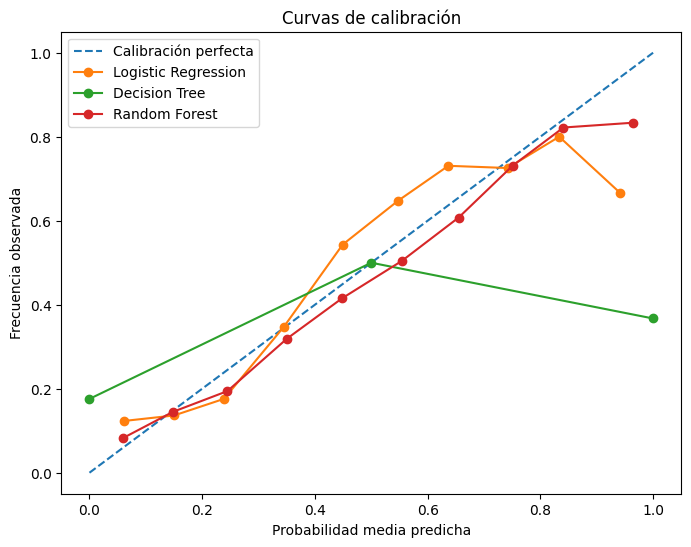

In [16]:
prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_proba_lr, n_bins=10, strategy="uniform")
prob_true_tree, prob_pred_tree = calibration_curve(y_test, y_proba_tree, n_bins=10, strategy="uniform")
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_proba_rf, n_bins=10, strategy="uniform")

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Logistic Regression")
plt.plot(prob_pred_tree, prob_true_tree, marker="o", label="Decision Tree")
plt.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")

plt.xlabel("Probabilidad media predicha")
plt.ylabel("Frecuencia observada")
plt.title("Curvas de calibración")
plt.legend()
plt.show()



La gráfica de calibración permite comparar qué tan bien coinciden las probabilidades predichas por cada modelo con las frecuencias observadas de incumplimiento.

### Regresión logística
La curva de la regresión logística se mantiene relativamente cerca de la diagonal en varios tramos, aunque muestra algunas desviaciones en probabilidades medias y altas. En general, su comportamiento sugiere una calibración razonable, aunque no perfecta.

### Árbol de decisión
La curva del árbol de decisión presenta desviaciones más marcadas y un comportamiento más irregular. Esto es consistente con lo observado anteriormente: al producir probabilidades extremas, el árbol tiende a estar peor calibrado y a generar estimaciones menos confiables.

### Random Forest
La curva de Random Forest se mantiene bastante cerca de la diagonal en buena parte del rango, especialmente en probabilidades bajas y medias. Aunque también presenta algunas desviaciones en la zona alta, en conjunto parece ofrecer una calibración más estable que el árbol de decisión y competitiva frente a la regresión logística.

### Interpretación general
Visualmente, la comparación sugiere que:

- el **árbol de decisión** es el modelo peor calibrado,
- la **regresión logística** presenta una calibración razonable,
- y **Random Forest** parece combinar buena discriminación con una calibración también bastante aceptable.

Esto es consistente con los resultados del **Brier score**, donde Random Forest obtuvo el menor valor, seguido por la regresión logística, mientras que el árbol de decisión quedó claramente rezagado.

## Tabla de apoyo para las curvas de calibración

Para interpretar mejor las curvas, se mostrarán las parejas de valores usadas en la gráfica:

- `prob_pred`: probabilidad media predicha en cada grupo,
- `prob_true`: frecuencia observada de incumplimiento en ese grupo.

Esto permite inspeccionar de forma más concreta dónde cada modelo sobreestima o subestima el riesgo.

In [17]:
calibration_df = pd.DataFrame({
    "prob_pred_lr": pd.Series(prob_pred_lr),
    "prob_true_lr": pd.Series(prob_true_lr),
    "prob_pred_tree": pd.Series(prob_pred_tree),
    "prob_true_tree": pd.Series(prob_true_tree),
    "prob_pred_rf": pd.Series(prob_pred_rf),
    "prob_true_rf": pd.Series(prob_true_rf)
})

calibration_df

,prob_pred_lr,prob_true_lr,prob_pred_tree,prob_true_tree,prob_pred_rf,prob_true_rf
0,0.0616,0.1233,0.0000,0.1758,0.0597,0.0827
1,0.1499,0.1363,0.5000,0.5000,0.1481,0.1449
2,0.2387,0.1759,1.0000,0.3672,0.2447,0.1944
3,0.3451,0.3478,NaN,NaN,0.3503,0.3190
4,0.4493,0.5432,NaN,NaN,0.4481,0.4152
5,0.5477,0.6478,NaN,NaN,0.5541,0.5042
6,0.6367,0.7308,NaN,NaN,0.6549,0.6074
7,0.7419,0.7255,NaN,NaN,0.7509,0.7312
8,0.8334,0.8000,NaN,NaN,0.8410,0.8219
9,0.9412,0.6667,NaN,NaN,0.9643,0.8333




La tabla permite observar con más detalle cómo se comporta cada modelo en distintos niveles de probabilidad predicha.

### Regresión logística
En los primeros intervalos, la regresión logística tiende a **subestimar** el riesgo, ya que la frecuencia observada (`prob_true_lr`) es mayor que la probabilidad media predicha (`prob_pred_lr`). En los intervalos intermedios la curva se acerca más a la diagonal, y en la parte alta aparecen algunas desviaciones, lo que coincide con la gráfica de calibración.

### Árbol de decisión
El árbol de decisión sólo muestra pocos puntos efectivos, porque sus probabilidades se concentran en valores muy extremos (`0`, `0.5` y `1`). Esto confirma que el modelo no distribuye bien sus probabilidades a lo largo del rango completo y que su calibración resulta muy pobre.

Por ejemplo:

- cuando predice `1.0`, la frecuencia observada es sólo **0.3672**,

lo que indica una **sobreestimación fuerte** del riesgo en ese grupo.

### Random Forest
Random Forest presenta una secuencia mucho más gradual de probabilidades predichas, y en general los valores observados (`prob_true_rf`) evolucionan de forma consistente con los valores predichos (`prob_pred_rf`).

Aunque en varios tramos la frecuencia observada es menor que la probabilidad predicha, la relación entre ambas es más estable y cercana a la diagonal que en el árbol de decisión. Esto sugiere una calibración más razonable.

### Interpretación general
La tabla refuerza las conclusiones visuales:

- el **árbol de decisión** muestra una calibración claramente deficiente,
- la **regresión logística** tiene una calibración razonable, con algunas desviaciones,
- y **Random Forest** ofrece una calibración bastante estable, además de la mejor capacidad discriminante entre los tres modelos.

## Comparación final: discriminación vs calibración

En esta sesión se compararon dos dimensiones distintas del desempeño probabilístico:

- **discriminación**, medida con `ROC-AUC`,
- **calibración**, medida con `Brier score` y curvas de calibración.

Esta comparación es importante porque un modelo puede ordenar bien a los clientes por riesgo, pero al mismo tiempo producir probabilidades poco realistas.

In [21]:
resumen_final = resumen_calibracion.copy()
resumen_final["Ranking ROC-AUC"] = resumen_final["ROC-AUC"].rank(ascending=False, method="min")
resumen_final["Ranking Brier"] = resumen_final["Brier score"].rank(ascending=True, method="min")

resumen_final

,ROC-AUC,Brier score,Ranking ROC-AUC,Ranking Brier
Logistic Regression,0.7102,0.1466,2.0000,2.0000
Decision Tree,0.6005,0.2837,3.0000,3.0000
Random Forest,0.7575,0.1394,1.0000,1.0000



La tabla final resume de manera clara el comportamiento de los tres modelos en dos dimensiones clave del desempeño probabilístico:

### Discriminación
Medida con **ROC-AUC**, evalúa qué tan bien el modelo distingue entre clientes con y sin incumplimiento.

### Calibración
Medida con **Brier score**, evalúa qué tan cercanas son las probabilidades predichas a los resultados reales observados.

### Resultados
- **Random Forest** ocupa el **primer lugar** tanto en `ROC-AUC` como en `Brier score`.
- **Regresión logística** ocupa el **segundo lugar** en ambas métricas.
- **Árbol de decisión** queda en **tercer lugar** en los dos criterios.

### Interpretación general
Esto sugiere que **Random Forest** no sólo es el modelo con mejor capacidad para ordenar a los clientes según su riesgo, sino también el que produce las probabilidades más confiables entre los tres modelos comparados.

La **regresión logística** sigue siendo una alternativa sólida y estable, especialmente por su interpretación sencilla y su calibración razonable.

En cambio, el **árbol de decisión** resulta claramente inferior tanto en discriminación como en calibración, por lo que en su forma actual no parece ser la mejor opción para estimar probabilidades de incumplimiento.

## Conclusiones de la séptima sesión

En esta sesión se estudió la calidad de las probabilidades predichas por tres modelos:

- **regresión logística**,
- **árbol de decisión**,
- **Random Forest**.

Los principales hallazgos fueron los siguientes:

1. No basta con que un modelo clasifique bien; también es importante que sus probabilidades sean **creíbles** o **bien calibradas**.
2. El **Brier score** permitió medir el error probabilístico de cada modelo:
   - cuanto menor es su valor, mejor es la calidad de las probabilidades predichas.
3. Las curvas de calibración mostraron diferencias claras entre los tres enfoques:
   - el **árbol de decisión** tuvo la calibración más deficiente,
   - la **regresión logística** mostró una calibración razonable,
   - y **Random Forest** ofreció una calibración bastante estable.
4. Random Forest obtuvo:
   - el mejor **ROC-AUC**,
   - y el mejor **Brier score**,
   lo que indica que fue el modelo más sólido tanto en discriminación como en calibración.
5. La regresión logística sigue siendo una referencia importante por su estabilidad e interpretabilidad, aunque su capacidad discriminante es menor que la de Random Forest.
6. El árbol de decisión, en cambio, mostró limitaciones importantes en su forma actual, especialmente por la brusquedad de sus probabilidades.

En conjunto, los resultados sugieren que **Random Forest** es, hasta este punto del proyecto, el mejor modelo para estimar riesgo de incumplimiento en este conjunto de datos, ya que combina:

- buena capacidad discriminante,
- mejor calidad probabilística,
- y una estructura más robusta que un árbol individual.



## Tarea de la séptima sesión

Con base en los resultados, realizar lo siguiente:

1. Elaborar una tabla comparativa con:
   - ROC-AUC,
   - Brier score,
   - ranking de discriminación,
   - ranking de calibración.

2. Redactar un párrafo donde expliques con tus palabras:
   - qué mide el **ROC-AUC**,
   - qué mide el **Brier score**,
   - y por qué ambas métricas no evalúan exactamente lo mismo.

3. Revisar las curvas de calibración y responder:
   - ¿qué modelo parece mejor calibrado?
   - ¿qué modelo parece peor calibrado?
   - ¿qué significa que una curva quede por debajo de la diagonal?
   - ¿qué significa que una curva quede por encima de la diagonal?

4. Redactar una conclusión breve indicando:
   - cuál modelo elegirías para este problema,
   - y por qué.

